<a href="https://colab.research.google.com/github/HakumenWorld/Digital-Skola/blob/main/REF_Google_Drive_Detailed.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ✈️ Airline Flight Price Prediction — Google Drive Version

**Problem type:** Regression  
**Dataset:** Airlines Flights Data  
**Target:** `price`  
**Goal:** membuat model machine learning untuk memprediksi harga tiket pesawat berdasarkan informasi penerbangan.

Notebook ini sudah disesuaikan untuk dijalankan di **Google Colab** dengan dataset yang disimpan di **Google Drive**.

Sebelum menjalankan notebook:
1. Upload file `airlines_flights_data.csv` ke Google Drive.
2. Simpan file tersebut pada folder `MyDrive/Dataset/`.
3. Jika nama folder atau nama file berbeda, ubah variabel `DATASET_FOLDER` atau `DATASET_FILENAME` pada bagian pemuatan dataset.
4. Jalankan semua sel secara berurutan dari atas ke bawah.

Perbaikan utama notebook:
1. Dataset dibaca langsung dari Google Drive, bukan dari upload sementara Colab.
2. Lokasi file dan kolom wajib divalidasi sebelum analisis dimulai.
3. Fitur turunan `route` dibuat dari `source_city` dan `destination_city`.
4. Duplicate setelah penghapusan `flight` dan `index` dibuang agar evaluasi lebih jujur.
5. Data dibagi menjadi train, validation, dan test secara terstratifikasi berdasarkan `class`.
6. Model final dan metadata disimpan kembali ke Google Drive agar tidak hilang ketika runtime Colab berakhir.


## 0. Setup dan Import Library

Bagian ini memuat seluruh library yang digunakan untuk pengolahan data, visualisasi, preprocessing, pelatihan model, evaluasi, dan penyimpanan model. Penjelasan rinci tersedia tepat setelah sel kode.


In [1]:
# Library standar Python untuk pengelolaan file, JSON, peringatan, dan path.
import os
import json
import warnings
from pathlib import Path

# Library utama untuk perhitungan numerik dan pengolahan data berbentuk tabel.
import numpy as np
import pandas as pd

# Library untuk membuat visualisasi data.
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# Komponen scikit-learn untuk membagi data, preprocessing, dan pipeline.
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

# Beberapa algoritma regresi yang tersedia pada scikit-learn.
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# Metrik evaluasi regresi dan library penyimpanan model.
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    mean_absolute_percentage_error
)
import joblib

# Menyembunyikan warning nonkritis agar output notebook lebih bersih.
warnings.filterwarnings('ignore')

# Menampilkan seluruh kolom DataFrame dan membatasi angka desimal menjadi dua digit.
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

# Mengatur tema visualisasi Seaborn.
sns.set_theme(style='whitegrid')

# Nilai tetap untuk menjaga hasil sampling dan pembagian data tetap konsisten.
RANDOM_STATE = 42


#### Penjelasan kode: setup dan import library

- `os`, `json`, `warnings`, dan `Path` merupakan library standar Python. `json` dipakai untuk menyimpan metadata model, sedangkan `Path` mempermudah penyusunan lokasi file dan folder.
- `numpy` menyediakan operasi numerik, termasuk akar kuadrat pada RMSE. `pandas` dipakai untuk membaca CSV, mengolah DataFrame, melakukan grouping, dan membuat tabel ringkasan.
- `matplotlib.pyplot` dan `seaborn` digunakan untuk histogram, boxplot, bar chart, line plot, scatter plot, dan heatmap. `display` menampilkan DataFrame dengan format yang lebih rapi di notebook.
- `train_test_split` membagi dataset. `ColumnTransformer` menerapkan preprocessing yang berbeda pada kolom kategorikal dan numerik. `OneHotEncoder` mengubah kategori menjadi angka. `Pipeline` menyatukan preprocessing dan model.
- Kelas model scikit-learn diimpor sebagai kandidat atau komponen pendukung. Model eksternal XGBoost, LightGBM, dan CatBoost diimpor pada bagian terpisah karena mungkin perlu dipasang terlebih dahulu.
- MAE, MSE, R², dan MAPE digunakan untuk mengevaluasi performa regresi. `joblib` menyimpan pipeline final dalam file `.pkl`.
- `warnings.filterwarnings('ignore')` menyembunyikan warning nonkritis. Gunakan dengan hati-hati karena warning tertentu dapat membantu menemukan masalah kompatibilitas.
- Pengaturan pandas menampilkan seluruh kolom dan memformat angka dengan dua desimal. Tema `whitegrid` membuat grafik lebih mudah dibaca.
- `RANDOM_STATE = 42` menetapkan seed yang sama untuk sampling dan pembagian data. Seed membantu reproduksibilitas, tetapi tidak menjamin hasil identik pada seluruh versi library atau perangkat keras.


## 1. Menghubungkan Google Drive dan Memuat Dataset

Dataset tidak lagi diunggah ke penyimpanan sementara Google Colab. Notebook akan menghubungkan Google Drive, kemudian membaca file CSV dari folder yang ditentukan.

Struktur folder yang digunakan secara default:

```text
MyDrive/
└── Dataset/
    └── airlines_flights_data.csv
```

Keuntungan pendekatan ini adalah dataset tetap tersimpan meskipun runtime Google Colab dihentikan atau di-reset.


In [2]:
# Mengimpor fitur Google Drive yang tersedia di Google Colab.
from google.colab import drive

# Menghubungkan Google Drive ke folder /content/drive.
# Saat dijalankan, Colab akan meminta izin akses ke akun Google.
drive.mount('/content/drive')


Mounted at /content/drive


#### Penjelasan kode: menghubungkan Google Drive

- `from google.colab import drive` mengambil modul khusus Google Colab untuk mengakses Google Drive. Modul ini hanya tersedia ketika notebook dijalankan di Google Colab.
- `drive.mount('/content/drive')` memasang Google Drive ke sistem file Colab. Setelah proses otorisasi berhasil, folder `MyDrive` dapat diakses melalui `/content/drive/MyDrive`.
- Proses mount tidak menyalin seluruh isi Drive ke Colab. Colab hanya memperoleh jalur akses ke file yang tersimpan di Drive.
- Jika muncul pesan bahwa Drive sudah terpasang, notebook dapat dilanjutkan tanpa melakukan otorisasi ulang.


In [4]:
DRIVE_ROOT = Path('/content/drive/MyDrive/Digital Skola/Final Project')
DATASET_FOLDER = Path('Dataset')
DATASET_FILENAME = 'airlines_flights_data.csv'

# Menggabungkan root Drive dan nama file menjadi path lengkap.
data_path = DRIVE_ROOT / DATASET_FILENAME

# Memastikan file benar-benar tersedia sebelum dibaca.
if not data_path.exists():
    raise FileNotFoundError(
        f'Dataset tidak ditemukan pada: {data_path}\n'
        'Upload file ke Google Drive atau sesuaikan DATASET_FOLDER dan '
        'DATASET_FILENAME dengan lokasi file Anda.'
    )

# Membaca file CSV dari Google Drive menjadi DataFrame pandas.
df = pd.read_csv(data_path)

# Daftar kolom minimum yang dibutuhkan oleh seluruh proses analisis dan modelling.
required_columns = {
    'index', 'airline', 'flight', 'source_city', 'departure_time',
    'stops', 'arrival_time', 'destination_city', 'class',
    'duration', 'days_left', 'price'
}

# Menghitung kolom wajib yang tidak ditemukan dalam dataset.
missing_columns = required_columns.difference(df.columns)

# Menghentikan proses lebih awal jika struktur dataset tidak sesuai.
if missing_columns:
    raise ValueError(
        'Dataset berhasil dibaca, tetapi beberapa kolom wajib tidak tersedia: '
        f'{sorted(missing_columns)}'
    )

# Menampilkan informasi awal sebagai konfirmasi bahwa dataset berhasil dimuat.
print(f'Dataset berhasil dimuat dari: {data_path}')
print('Ukuran dataset:', df.shape)
display(df.head())

Dataset berhasil dimuat dari: /content/drive/MyDrive/Digital Skola/Final Project/airlines_flights_data.csv
Ukuran dataset: (300153, 12)


,index,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


#### Penjelasan kode: membaca dataset dari Google Drive

1. `DRIVE_ROOT` menunjuk ke folder utama Google Drive pengguna, yaitu `/content/drive/MyDrive`.
2. `DATASET_FOLDER` berisi nama folder tempat dataset disimpan. Nilai default-nya adalah `Dataset`. Ubah bagian ini jika file berada di folder lain, misalnya `Path('Kuliah/Machine Learning')`.
3. `DATASET_FILENAME` menyimpan nama file CSV. Nama harus sama persis dengan file di Google Drive, termasuk huruf besar, huruf kecil, spasi, dan ekstensi.
4. Operator `/` pada objek `Path` menggabungkan beberapa bagian lokasi file secara aman. Hasil akhirnya adalah `/content/drive/MyDrive/Dataset/airlines_flights_data.csv`.
5. `data_path.exists()` memeriksa keberadaan file. Jika file tidak ditemukan, `FileNotFoundError` menampilkan lokasi yang sedang dicari sehingga pengguna dapat memperbaiki folder atau nama file.
6. `pd.read_csv(data_path)` membaca isi CSV dan menyimpannya ke variabel `df` dalam bentuk DataFrame. DataFrame adalah struktur tabel utama pada pandas.
7. `required_columns` menentukan kolom minimum yang dibutuhkan notebook. Validasi ini mencegah error yang membingungkan pada bagian berikutnya jika pengguna memakai dataset yang salah atau nama kolom berubah.
8. `required_columns.difference(df.columns)` mencari kolom wajib yang belum tersedia. Jika hasilnya tidak kosong, notebook dihentikan melalui `ValueError`.
9. `df.shape` menampilkan jumlah baris dan kolom. `df.head()` menampilkan lima baris pertama untuk memastikan isi dataset sudah benar.


## 2. Data Understanding

Pada bagian ini kita cek struktur data, tipe data, statistik deskriptif, dan jumlah nilai unik tiap kolom.

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   index             300153 non-null  int64  
 1   airline           300153 non-null  object 
 2   flight            300153 non-null  object 
 3   source_city       300153 non-null  object 
 4   departure_time    300153 non-null  object 
 5   stops             300153 non-null  object 
 6   arrival_time      300153 non-null  object 
 7   destination_city  300153 non-null  object 
 8   class             300153 non-null  object 
 9   duration          300153 non-null  float64
 10  days_left         300153 non-null  int64  
 11  price             300153 non-null  int64  
dtypes: float64(1), int64(3), object(8)
memory usage: 27.5+ MB


#### Penjelasan kode: struktur dataset

- `df.info()` memberikan ringkasan teknis DataFrame.
- Output mencakup jumlah baris, nama kolom, jumlah nilai non-null, tipe data setiap kolom, dan perkiraan penggunaan memori.
- Bagian `Non-Null Count` membantu mendeteksi nilai kosong. Jika jumlah non-null lebih kecil daripada jumlah baris, kolom tersebut memiliki missing value.
- Bagian `Dtype` menunjukkan apakah kolom dibaca sebagai angka, teks, atau tipe lain. Informasi ini penting sebelum preprocessing dan modelling.


In [6]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
index,"300,153.00",NaN,NaN,NaN,"150,076.00","86,646.85",0.00,"75,038.00","150,076.00","225,114.00","300,152.00"
airline,300153,6,Vistara,127859,NaN,NaN,NaN,NaN,NaN,NaN,NaN
flight,300153,1561,UK-706,3235,NaN,NaN,NaN,NaN,NaN,NaN,NaN
source_city,300153,6,Delhi,61343,NaN,NaN,NaN,NaN,NaN,NaN,NaN
departure_time,300153,6,Morning,71146,NaN,NaN,NaN,NaN,NaN,NaN,NaN
stops,300153,3,one,250863,NaN,NaN,NaN,NaN,NaN,NaN,NaN
arrival_time,300153,6,Night,91538,NaN,NaN,NaN,NaN,NaN,NaN,NaN
destination_city,300153,6,Mumbai,59097,NaN,NaN,NaN,NaN,NaN,NaN,NaN
class,300153,2,Economy,206666,NaN,NaN,NaN,NaN,NaN,NaN,NaN
duration,"300,153.00",NaN,NaN,NaN,12.22,7.19,0.83,6.83,11.25,16.17,49.83


#### Penjelasan kode: statistik deskriptif

- `df.describe(include='all')` menghitung statistik untuk seluruh kolom, termasuk kolom numerik dan kategorikal.
- Untuk kolom numerik, hasil utama meliputi jumlah data, rata-rata, standar deviasi, nilai minimum, kuartil, dan maksimum.
- Untuk kolom kategorikal, hasilnya meliputi jumlah data, jumlah kategori unik, kategori yang paling sering muncul, dan frekuensinya.
- `.T` melakukan transpose agar setiap kolom dataset ditampilkan sebagai baris. Bentuk ini lebih mudah dibaca ketika dataset memiliki banyak variabel.


In [7]:
unique_summary = pd.DataFrame({
    'column': df.columns,
    'dtype': df.dtypes.astype(str).values,
    'n_unique': df.nunique().values,
    'sample_values': [df[col].dropna().unique()[:5].tolist() for col in df.columns]
})
unique_summary

,column,dtype,n_unique,sample_values
0,index,int64,300153,"[0, 1, 2, 3, 4]"
1,airline,object,6,"[SpiceJet, AirAsia, Vistara, GO_FIRST, Indigo]"
2,flight,object,1561,"[SG-8709, SG-8157, I5-764, UK-995, UK-963]"
3,source_city,object,6,"[Delhi, Mumbai, Bangalore, Kolkata, Hyderabad]"
4,departure_time,object,6,"[Evening, Early_Morning, Morning, Afternoon, N..."
5,stops,object,3,"[zero, one, two_or_more]"
6,arrival_time,object,6,"[Night, Morning, Early_Morning, Afternoon, Eve..."
7,destination_city,object,6,"[Mumbai, Bangalore, Kolkata, Hyderabad, Chennai]"
8,class,object,2,"[Economy, Business]"
9,duration,float64,476,"[2.17, 2.33, 2.25, 2.08, 12.25]"


#### Penjelasan kode: tipe data, jumlah kategori, dan contoh nilai

- `df.columns` mengambil seluruh nama kolom.
- `df.dtypes.astype(str).values` mengambil tipe data setiap kolom dan mengubahnya menjadi teks agar mudah dimasukkan ke tabel ringkasan.
- `df.nunique()` menghitung jumlah nilai unik pada setiap kolom. Nilai ini membantu mengidentifikasi kolom berkardinalitas tinggi, seperti kode penerbangan.
- List comprehension pada `sample_values` mengambil maksimal lima contoh nilai unik dari setiap kolom setelah nilai kosong dibuang.
- Seluruh informasi disatukan ke dalam `unique_summary`, sehingga struktur dan variasi data dapat diperiksa dalam satu tabel.


### Ringkasan awal

- Dataset berisi data penerbangan dari beberapa maskapai, kota asal, kota tujuan, waktu keberangkatan/kedatangan, kelas, durasi, hari sebelum keberangkatan, dan harga.
- Target `price` berupa angka, sehingga problem ini termasuk **regression**.
- Kolom `index` hanya nomor urut.
- Kolom `flight` memiliki cardinality tinggi. Untuk versi deployment yang mudah dipakai user, kolom ini tidak digunakan.

## 3. Data Quality Check

Kita cek missing value dan duplicate row pada data mentah.

In [8]:
missing = df.isna().sum().sort_values(ascending=False)
duplicate_count_raw = df.duplicated().sum()

print("Total missing values:", missing.sum())
print("Total duplicate rows in raw data:", duplicate_count_raw)

quality_summary = pd.DataFrame({
    'missing_count': df.isna().sum(),
    'missing_percentage': (df.isna().mean() * 100).round(2),
    'n_unique': df.nunique()
})
quality_summary

Total missing values: 0
Total duplicate rows in raw data: 0


,missing_count,missing_percentage,n_unique
index,0,0.00,300153
airline,0,0.00,6
flight,0,0.00,1561
source_city,0,0.00,6
departure_time,0,0.00,6
stops,0,0.00,3
arrival_time,0,0.00,6
destination_city,0,0.00,6
class,0,0.00,2
duration,0,0.00,476


#### Penjelasan kode: missing value dan duplicate

- `df.isna()` menghasilkan tabel Boolean. Nilai `True` menunjukkan data kosong.
- `.sum()` menghitung jumlah nilai kosong pada setiap kolom. `.sort_values(ascending=False)` menempatkan kolom dengan missing value terbanyak di bagian atas.
- `df.duplicated().sum()` menghitung jumlah baris yang seluruh nilainya sama dengan baris sebelumnya.
- `missing.sum()` memberikan total missing value dari semua kolom.
- `missing_percentage` dihitung dari proporsi nilai kosong dikalikan 100, sehingga tingkat masalah dapat dibandingkan antar kolom.
- `quality_summary` menyatukan jumlah missing value, persentase missing value, dan jumlah nilai unik sebagai dasar pengambilan keputusan cleaning.


## 4. Data Cleaning & Feature Engineering

Langkah revisi:

1. Drop `index` karena hanya nomor urut.
2. Drop `flight` karena terlalu spesifik dan membuat input Streamlit kurang ramah pengguna.
3. Tambahkan fitur `route` dari kombinasi `source_city` dan `destination_city`.
4. Setelah `flight` dibuang, beberapa baris bisa menjadi duplicate secara fitur dan target. Duplicate ini kita drop khusus untuk modelling agar train-test evaluation tidak terlalu optimistis.

Catatan: duplicate setelah feature selection bukan berarti data mentah salah. Ini terjadi karena beberapa flight berbeda bisa memiliki informasi input yang sama setelah kode flight dihilangkan.

In [9]:
df_clean = df.copy()

columns_to_drop = ['index', 'flight']
df_clean = df_clean.drop(columns=columns_to_drop)

# Feature engineering sederhana: route penerbangan
# Streamlit nanti menghitung route otomatis dari source_city dan destination_city.
df_clean['route'] = df_clean['source_city'].astype(str) + ' → ' + df_clean['destination_city'].astype(str)

# Rapikan urutan kolom agar target price berada paling belakang
feature_cols = [col for col in df_clean.columns if col != 'price']
df_clean = df_clean[feature_cols + ['price']]

print("Shape raw data                 :", df.shape)
print("Shape after feature selection  :", df_clean.shape)
print("Duplicate after feature select :", df_clean.duplicated().sum())
print("Columns used for modelling:")
print(df_clean.columns.tolist())

df_clean.head()

Shape raw data                 : (300153, 12)
Shape after feature selection  : (300153, 11)
Duplicate after feature select : 2213
Columns used for modelling:
['airline', 'source_city', 'departure_time', 'stops', 'arrival_time', 'destination_city', 'class', 'duration', 'days_left', 'route', 'price']


,airline,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,route,price
0,SpiceJet,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,Delhi → Mumbai,5953
1,SpiceJet,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,Delhi → Mumbai,5953
2,AirAsia,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,Delhi → Mumbai,5956
3,Vistara,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,Delhi → Mumbai,5955
4,Vistara,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,Delhi → Mumbai,5955


#### Penjelasan kode: pemilihan fitur dan pembuatan route

- `df.copy()` membuat salinan dataset. Perubahan pada `df_clean` tidak akan mengubah data mentah pada `df`.
- `columns_to_drop` berisi `index` dan `flight`. `index` hanya nomor urut, sedangkan `flight` memiliki banyak nilai unik dan tidak dipakai pada rancangan input aplikasi.
- `drop(columns=columns_to_drop)` menghapus kedua kolom tersebut.
- Fitur `route` dibuat dengan menggabungkan `source_city`, simbol panah, dan `destination_city`. Contohnya adalah `Delhi → Mumbai`.
- `astype(str)` memastikan kedua kolom kota dapat digabungkan sebagai teks.
- Daftar `feature_cols` mengambil semua kolom kecuali target `price`, kemudian `price` dipindahkan ke posisi paling akhir agar struktur data lebih mudah dibaca.
- Baris `print` membandingkan ukuran data sebelum dan sesudah pemilihan fitur serta menampilkan duplicate yang muncul setelah kode penerbangan dihapus.


In [10]:
df_model = df_clean.drop_duplicates().reset_index(drop=True)

print("Rows before removing selected-feature duplicates:", len(df_clean))
print("Rows after removing selected-feature duplicates :", len(df_model))
print("Rows removed:", len(df_clean) - len(df_model))
print("Missing values after cleaning:", df_model.isna().sum().sum())
print("Duplicate rows after cleaning:", df_model.duplicated().sum())

Rows before removing selected-feature duplicates: 300153
Rows after removing selected-feature duplicates : 297940
Rows removed: 2213
Missing values after cleaning: 0
Duplicate rows after cleaning: 0


#### Penjelasan kode: menghapus duplicate setelah pemilihan fitur

- `drop_duplicates()` menghapus baris yang identik berdasarkan seluruh kolom yang tersisa, termasuk target `price`.
- Duplicate dapat muncul karena beberapa kode penerbangan berbeda menjadi identik setelah kolom `flight` dihapus.
- `reset_index(drop=True)` membuat ulang indeks dari 0 dan membuang indeks lama.
- Jumlah baris sebelum dan sesudah cleaning ditampilkan agar dampak penghapusan duplicate dapat diaudit.
- Missing value dan duplicate diperiksa ulang untuk memastikan data modelling sudah bersih.


## 5. Exploratory Data Analysis (EDA)

EDA difokuskan pada hubungan fitur dengan harga tiket:
- Distribusi `price`.
- Perbedaan harga berdasarkan `class`, `airline`, dan `stops`.
- Pola harga berdasarkan route dan days left.
- Hubungan fitur numerik dengan target.

### 5.1 Distribusi Target `price`

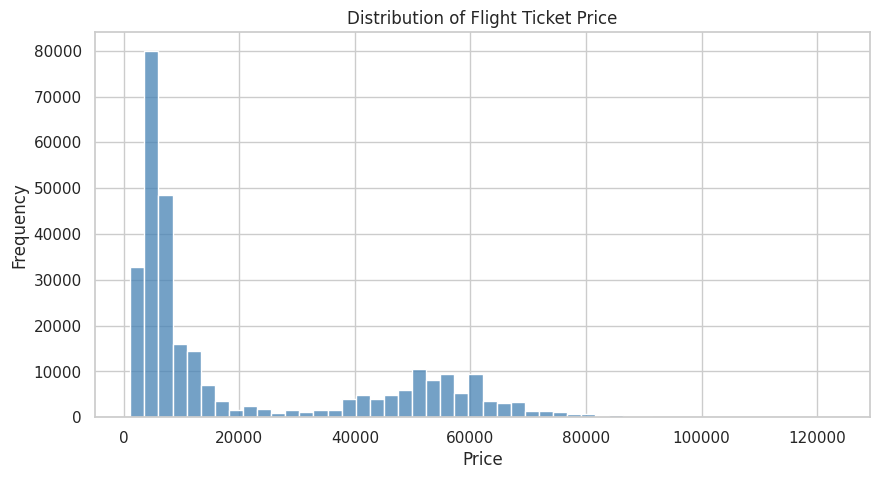

,price
count,"297,940.00"
mean,"20,976.45"
std,"22,734.39"
min,"1,105.00"
1%,"1,788.00"
5%,"2,464.00"
50%,"7,466.00"
95%,"63,277.00"
99%,"76,829.00"
max,"123,071.00"


In [11]:
plt.figure(figsize=(10, 5))
sns.histplot(df_model['price'], bins=50, kde=False, color='steelblue')
plt.title('Distribution of Flight Ticket Price')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

price_stats = df_model['price'].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99])
price_stats

#### Penjelasan kode: distribusi harga tiket

- `plt.figure(figsize=(10, 5))` membuat area grafik berukuran 10 × 5 inci.
- `sns.histplot()` membagi nilai `price` ke dalam 50 interval dan menghitung frekuensi pada setiap interval.
- `kde=False` menonaktifkan kurva estimasi kepadatan agar fokus tetap pada histogram aktual.
- Judul dan label sumbu menjelaskan isi grafik.
- `describe(percentiles=[...])` menghitung statistik harga beserta persentil 1%, 5%, 50%, 95%, dan 99%. Persentil membantu menilai sebaran nilai ekstrem tanpa langsung menghapusnya.


**Insight:** Distribusi `price` cenderung right-skewed. Mayoritas tiket berada di harga rendah sampai menengah, sementara sebagian kecil tiket memiliki harga sangat tinggi, biasanya dipengaruhi kelas Business, route, dan durasi.

### 5.2 Harga Berdasarkan Class

,count,mean,median,min,max
class,,,,,
Business,93173,"52,591.35","53,164.00",12000,123071
Economy,204767,"6,591.05","5,780.00",1105,42349


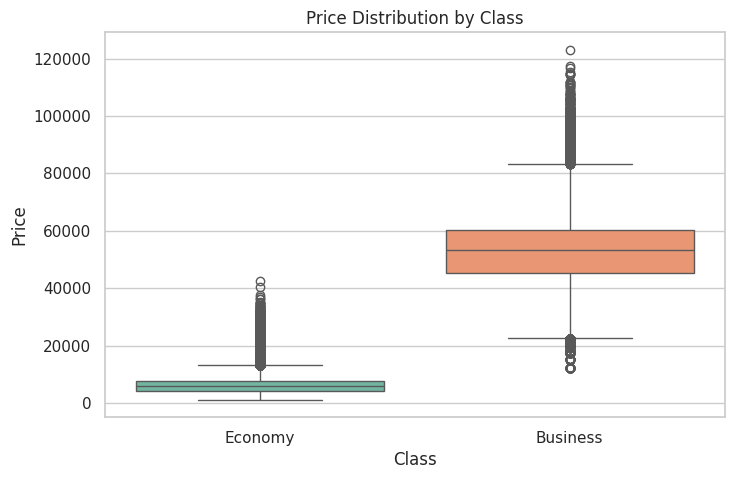

In [12]:
class_summary = df_model.groupby('class')['price'].agg(['count', 'mean', 'median', 'min', 'max']).sort_values('mean', ascending=False)
display(class_summary)

plt.figure(figsize=(8, 5))
sns.boxplot(data=df_model, x='class', y='price', palette='Set2')
plt.title('Price Distribution by Class')
plt.xlabel('Class')
plt.ylabel('Price')
plt.show()

#### Penjelasan kode: perbandingan harga berdasarkan kelas

- `groupby('class')['price']` mengelompokkan harga berdasarkan kelas penerbangan.
- `.agg(['count', 'mean', 'median', 'min', 'max'])` menghitung jumlah observasi, rata-rata, median, nilai minimum, dan maksimum untuk setiap kelas.
- `.sort_values('mean', ascending=False)` mengurutkan kelas dari rata-rata harga tertinggi.
- Boxplot memperlihatkan median, kuartil, rentang utama, dan nilai ekstrem setiap kelas.
- Perbandingan ini membantu menilai seberapa besar perbedaan harga antara Economy dan Business.


**Insight:** `class` sangat berpengaruh. Business memiliki rata-rata dan median harga jauh lebih tinggi dibanding Economy.

### 5.3 Harga Berdasarkan Airline

,count,mean,median
airline,,,
Vistara,126962,"30,494.72","15,624.00"
Air_India,80882,"23,507.89","11,520.00"
SpiceJet,8636,"6,210.62","5,654.00"
GO_FIRST,22979,"5,668.46","5,379.00"
Indigo,42470,"5,348.72","4,453.00"
AirAsia,16011,"4,099.47","3,282.00"


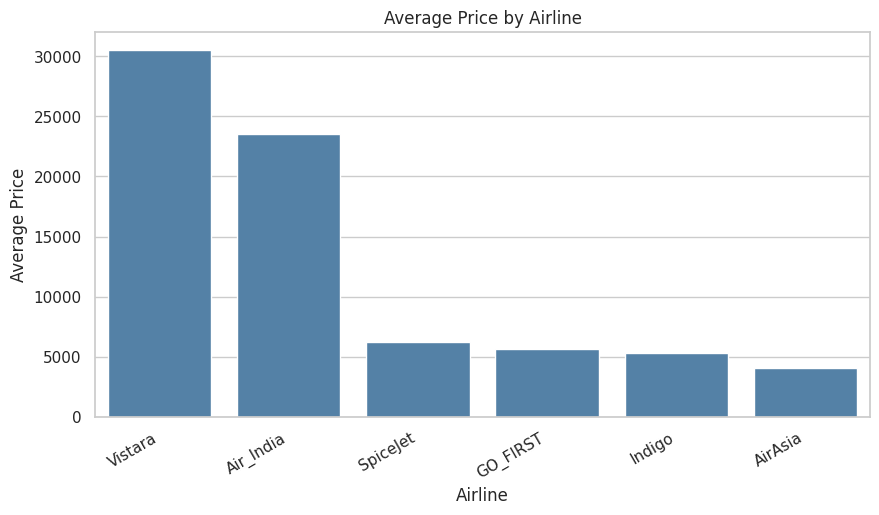

In [13]:
airline_price = df_model.groupby('airline')['price'].agg(['count', 'mean', 'median']).sort_values('mean', ascending=False)
display(airline_price)

plt.figure(figsize=(10, 5))
sns.barplot(data=airline_price.reset_index(), x='airline', y='mean', color='steelblue')
plt.title('Average Price by Airline')
plt.xlabel('Airline')
plt.ylabel('Average Price')
plt.xticks(rotation=30, ha='right')
plt.show()

#### Penjelasan kode: rata-rata harga tiap maskapai

- Data dikelompokkan berdasarkan `airline`, kemudian dihitung jumlah data, rata-rata, dan median harga.
- Pengurutan berdasarkan rata-rata memudahkan identifikasi maskapai dengan harga relatif tinggi.
- `reset_index()` mengubah indeks hasil grouping menjadi kolom biasa agar dapat digunakan oleh Seaborn.
- Bar chart menampilkan rata-rata harga setiap maskapai.
- Label maskapai diputar 30 derajat agar tidak saling bertumpuk.


**Insight:** Harga rata-rata berbeda antar maskapai karena tiap airline memiliki segmentasi, route, dan proporsi class yang berbeda.

### 5.4 Harga Berdasarkan Jumlah Transit (`stops`)

,count,mean,median
stops,,,
one,250314,"22,927.07","7,971.00"
two_or_more,13285,"14,113.63","8,307.00"
zero,34341,"9,413.17","4,498.00"


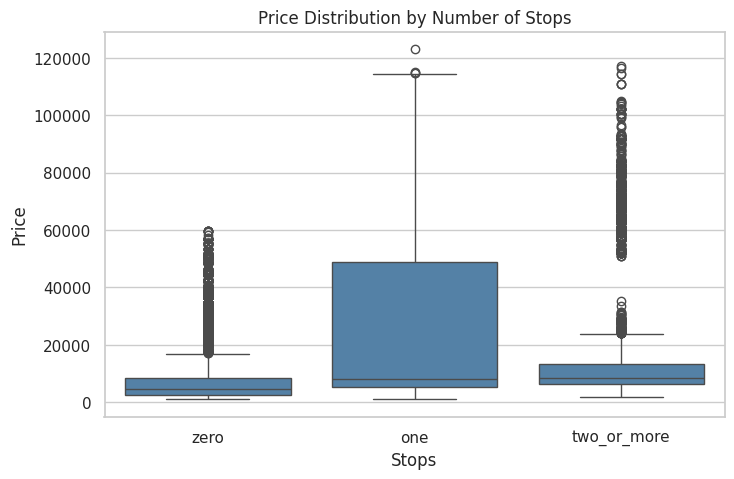

In [14]:
stops_price = df_model.groupby('stops')['price'].agg(['count', 'mean', 'median']).sort_values('mean', ascending=False)
display(stops_price)

plt.figure(figsize=(8, 5))
sns.boxplot(data=df_model, x='stops', y='price', color='steelblue')
plt.title('Price Distribution by Number of Stops')
plt.xlabel('Stops')
plt.ylabel('Price')
plt.show()

#### Penjelasan kode: harga berdasarkan jumlah transit

- `groupby('stops')` memisahkan penerbangan berdasarkan kategori transit.
- Statistik `count`, `mean`, dan `median` digunakan untuk membandingkan jumlah data dan kecenderungan harga tiap kategori.
- Boxplot memperlihatkan variasi harga di dalam setiap kategori transit, bukan hanya nilai rata-ratanya.
- Analisis ini tidak membuktikan hubungan sebab-akibat karena harga juga dipengaruhi kelas, rute, durasi, dan maskapai.


**Insight:** Jumlah transit berhubungan dengan harga, tetapi efeknya juga dipengaruhi route, duration, airline, dan class.

### 5.5 Harga Berdasarkan Route

,count,mean,median
route,,,
Chennai → Bangalore,6483,"25,118.31","10,469.00"
Kolkata → Chennai,6634,"23,712.24","8,701.50"
Bangalore → Chennai,6353,"23,509.95","9,420.00"
Bangalore → Kolkata,10001,"23,496.10","8,112.00"
Mumbai → Bangalore,12780,"23,297.05","7,332.00"
Bangalore → Mumbai,12851,"23,250.37","7,212.00"
Mumbai → Chennai,10080,"22,875.47","8,201.00"
Kolkata → Bangalore,9800,"22,789.18","8,111.00"
Chennai → Mumbai,9326,"22,788.94","8,233.00"


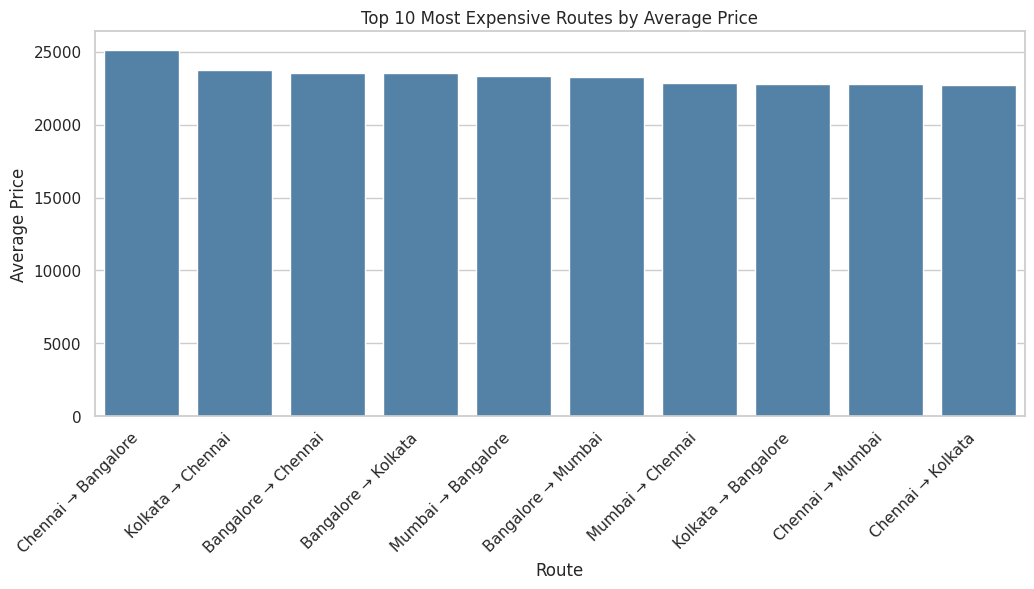

In [15]:
route_price = df_model.groupby('route')['price'].agg(['count', 'mean', 'median']).sort_values('mean', ascending=False)
display(route_price.head(10))

plt.figure(figsize=(12, 5))
sns.barplot(data=route_price.head(10).reset_index(), x='route', y='mean', color='steelblue')
plt.title('Top 10 Most Expensive Routes by Average Price')
plt.xlabel('Route')
plt.ylabel('Average Price')
plt.xticks(rotation=45, ha='right')
plt.show()

#### Penjelasan kode: rute dengan harga rata-rata tertinggi

- Dataset dikelompokkan berdasarkan fitur baru `route`.
- Jumlah penerbangan, rata-rata harga, dan median harga dihitung untuk setiap rute.
- `head(10)` mengambil sepuluh rute dengan rata-rata harga tertinggi setelah proses pengurutan.
- Bar chart menampilkan perbandingan visual antar rute.
- Perlu membaca kolom `count` bersama rata-rata. Rute dengan sangat sedikit observasi dapat menghasilkan rata-rata yang kurang stabil.


**Insight:** Route tertentu memiliki harga rata-rata lebih tinggi. Karena itu fitur `route` ditambahkan agar model lebih mudah menangkap kombinasi kota asal dan kota tujuan.

### 5.6 Pengaruh `days_left` terhadap Harga

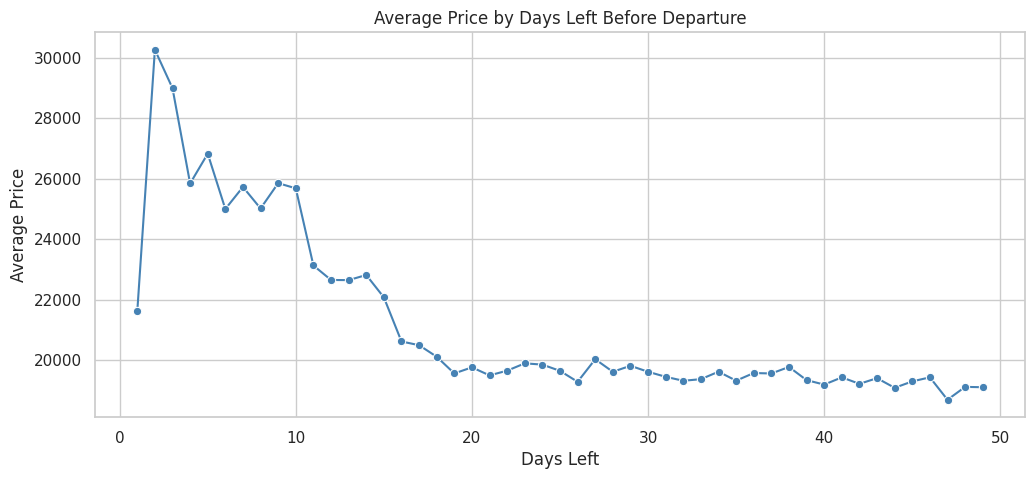

,days_left,price
0,1,"21,610.41"
1,2,"30,258.17"
2,3,"28,987.69"
3,4,"25,839.06"
4,5,"26,824.02"
5,6,"24,996.50"
6,7,"25,724.52"
7,8,"25,013.67"
8,9,"25,850.02"
9,10,"25,679.19"


In [16]:
days_price = df_model.groupby('days_left')['price'].mean().reset_index()

plt.figure(figsize=(12, 5))
sns.lineplot(data=days_price, x='days_left', y='price', marker='o', color='steelblue')
plt.title('Average Price by Days Left Before Departure')
plt.xlabel('Days Left')
plt.ylabel('Average Price')
plt.show()

days_price.head(10)

#### Penjelasan kode: hubungan waktu pemesanan dan harga

- Data dikelompokkan berdasarkan `days_left`, yaitu jumlah hari antara waktu pembelian dan keberangkatan.
- Rata-rata `price` dihitung untuk setiap nilai `days_left`.
- Line plot menunjukkan perubahan harga rata-rata ketika jarak menuju keberangkatan berubah.
- `marker='o'` memberi titik pada setiap observasi agregat sehingga pola lebih mudah diikuti.
- Tabel lima atau sepuluh baris awal digunakan untuk memeriksa nilai yang membentuk grafik.


**Insight:** `days_left` merepresentasikan jarak hari pembelian tiket sebelum keberangkatan. Harga bisa berbeda antara pembelian dekat tanggal berangkat dan pembelian lebih awal.

### 5.7 Hubungan `duration` dan `price`

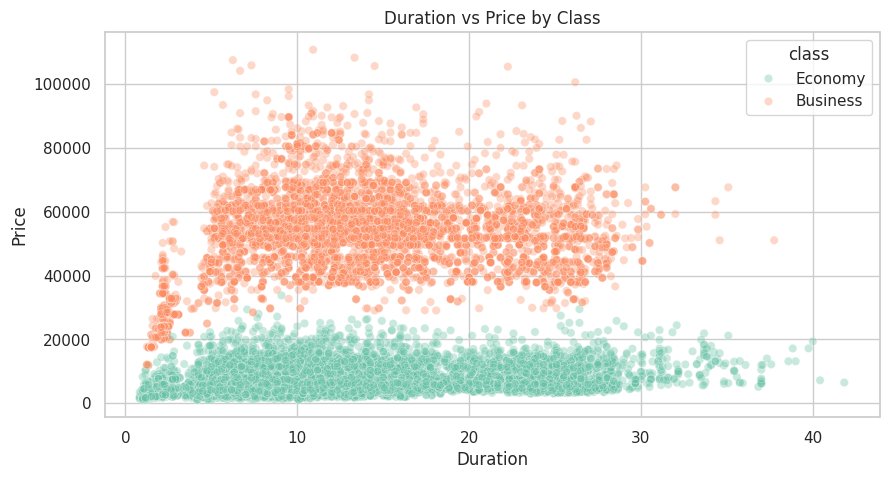

In [17]:
sample_df = df_model.sample(n=min(20000, len(df_model)), random_state=RANDOM_STATE)

plt.figure(figsize=(10, 5))
sns.scatterplot(data=sample_df, x='duration', y='price', hue='class', alpha=0.35, palette='Set2')
plt.title('Duration vs Price by Class')
plt.xlabel('Duration')
plt.ylabel('Price')
plt.show()

#### Penjelasan kode: hubungan durasi dan harga

- Maksimal 20.000 baris dipilih secara acak untuk menjaga grafik tetap ringan dan tidak terlalu padat.
- `random_state=RANDOM_STATE` membuat sampel yang sama dapat diperoleh pada setiap eksekusi.
- Scatter plot menempatkan `duration` pada sumbu X dan `price` pada sumbu Y.
- `hue='class'` membedakan titik berdasarkan kelas penerbangan.
- `alpha=0.35` membuat titik transparan sehingga area dengan kepadatan tinggi tetap terlihat.


**Insight:** Durasi berhubungan dengan harga, tetapi hubungan ini tidak sepenuhnya linear karena harga juga dipengaruhi class, airline, route, dan transit.

### 5.8 Korelasi Fitur Numerik

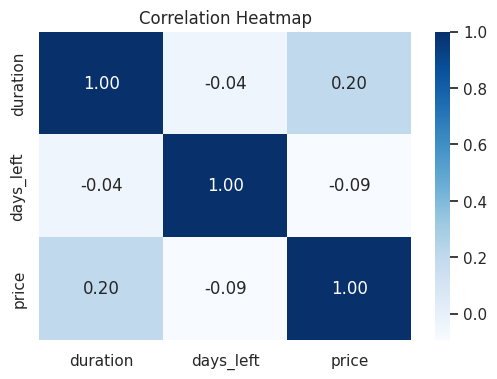

,duration,days_left,price
duration,1.00,-0.04,0.20
days_left,-0.04,1.00,-0.09
price,0.20,-0.09,1.00


In [18]:
numeric_corr = df_model[['duration', 'days_left', 'price']].corr()

plt.figure(figsize=(6, 4))
sns.heatmap(numeric_corr, annot=True, cmap='Blues', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

numeric_corr

#### Penjelasan kode: korelasi numerik

- Hanya `duration`, `days_left`, dan `price` yang dipilih karena ketiganya bersifat numerik.
- `.corr()` secara default menghitung korelasi Pearson, yaitu kekuatan hubungan linear antarvariabel.
- Nilai korelasi berkisar dari -1 sampai 1. Nilai mendekati 1 menunjukkan hubungan linear positif, mendekati -1 menunjukkan hubungan linear negatif, dan mendekati 0 menunjukkan hubungan linear lemah.
- Heatmap memberi representasi visual, sedangkan `annot=True` menampilkan nilai korelasi pada setiap sel.
- Korelasi tidak sama dengan kausalitas dan tidak menangkap hubungan non-linear secara penuh.


## 6. Pemeriksaan Outlier dan Distribusi

Normalisasi atau standardisasi **tidak menghilangkan outlier**. Pemeriksaan outlier dilakukan untuk memahami distribusi dan memastikan apakah nilai ekstrem merupakan kesalahan data atau observasi yang sah.

Pada dataset harga penerbangan, harga tinggi dapat menjadi nilai yang valid karena perbedaan kelas penerbangan. Oleh karena itu, outlier harga diperiksa per `class`, bukan langsung dihapus menggunakan batas global.

,count,mean,median,std,skewness,min,max
duration,297940,12.28,11.33,7.18,0.60,0.83,49.83
days_left,297940,26.00,26.00,13.56,-0.04,1.00,49.00
price,297940,"20,976.45","7,466.00","22,734.39",1.05,"1,105.00","123,071.00"


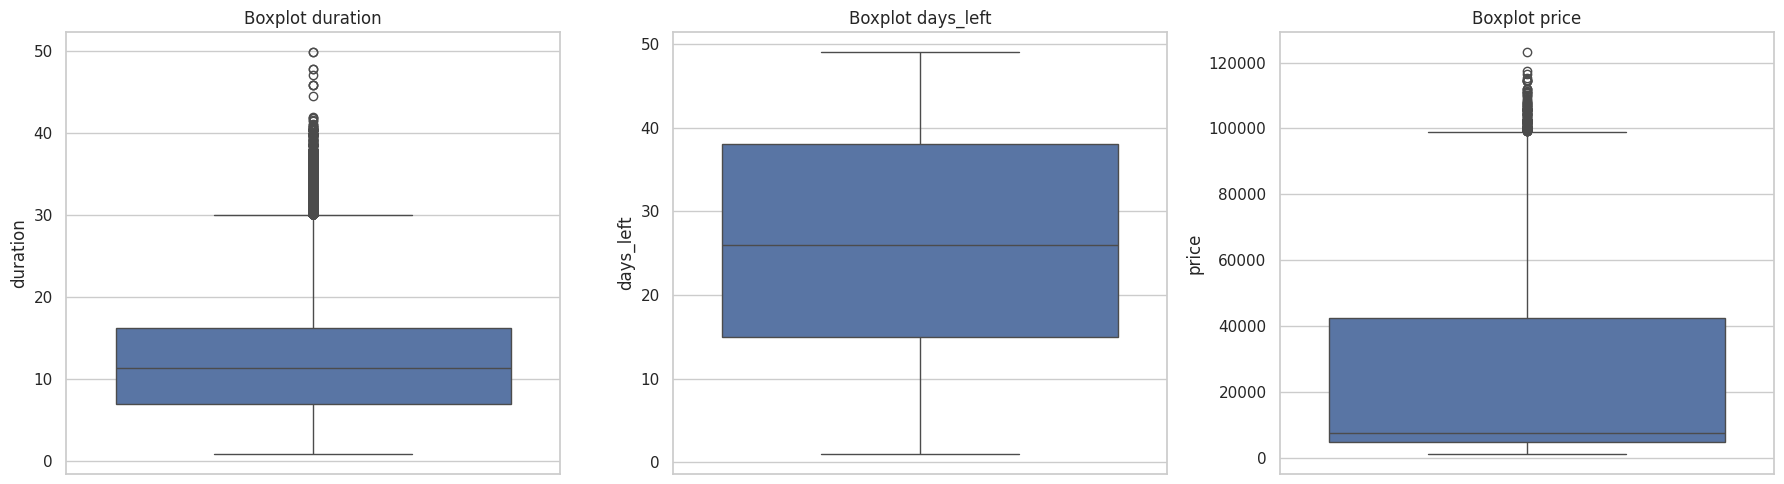

In [19]:
numeric_check_cols = ['duration', 'days_left', 'price']

distribution_summary = pd.DataFrame({
    'count': df_model[numeric_check_cols].count(),
    'mean': df_model[numeric_check_cols].mean(),
    'median': df_model[numeric_check_cols].median(),
    'std': df_model[numeric_check_cols].std(),
    'skewness': df_model[numeric_check_cols].skew(),
    'min': df_model[numeric_check_cols].min(),
    'max': df_model[numeric_check_cols].max()
})

display(distribution_summary)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, col in zip(axes, numeric_check_cols):
    sns.boxplot(y=df_model[col], ax=ax)
    ax.set_title(f'Boxplot {col}')
plt.tight_layout()
plt.show()

#### Penjelasan kode: ringkasan distribusi dan boxplot fitur numerik

- `numeric_check_cols` menentukan fitur numerik yang diperiksa.
- Tabel `distribution_summary` menghitung jumlah data, mean, median, standar deviasi, skewness, minimum, dan maksimum.
- Mean dan median dibandingkan untuk melihat indikasi distribusi miring.
- `skewness` mengukur kemencengan distribusi. Nilai positif menunjukkan ekor lebih panjang ke kanan.
- Tiga boxplot dibuat dalam satu baris untuk membandingkan rentang dan nilai ekstrem `duration`, `days_left`, dan `price`.
- Boxplot digunakan sebagai alat diagnosis. Nilai di luar whisker belum tentu salah.


In [20]:
def iqr_outlier_summary(data, column):
    q1 = data[column].quantile(0.25)
    q3 = data[column].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    mask = (data[column] < lower) | (data[column] > upper)

    return pd.Series({
        'Q1': q1,
        'Q3': q3,
        'IQR': iqr,
        'Lower Bound': lower,
        'Upper Bound': upper,
        'Outlier Count': int(mask.sum()),
        'Outlier Percentage': mask.mean() * 100
    })

global_outlier_summary = pd.DataFrame({
    col: iqr_outlier_summary(df_model, col)
    for col in numeric_check_cols
}).T

print('Pemeriksaan IQR global:')
display(global_outlier_summary)

price_outlier_by_class = (
    df_model.groupby('class', group_keys=False)
    .apply(lambda group: iqr_outlier_summary(group, 'price'))
    .unstack()
)

print('Pemeriksaan outlier price per class:')
display(price_outlier_by_class)

# Keputusan:
# Nilai ekstrem tidak dihapus otomatis karena dapat merepresentasikan harga tiket
# Business atau kondisi penerbangan yang valid. Hapus hanya jika terbukti salah input.

Pemeriksaan IQR global:


,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count,Outlier Percentage
duration,6.92,16.17,9.25,-6.96,30.05,"2,226.00",0.75
days_left,15.00,38.00,23.00,-19.50,72.50,0.00,0.00
price,"4,792.00","42,521.00","37,729.00","-51,801.50","99,114.50",123.00,0.04


Pemeriksaan outlier price per class:


class   
Q1                  Business   45,189.00
                    Economy     4,189.00
Q3                  Business   60,396.00
                    Economy     7,767.00
IQR                 Business   15,207.00
                    Economy     3,578.00
Lower Bound         Business   22,378.50
                    Economy    -1,178.00
Upper Bound         Business   83,206.50
                    Economy    13,134.00
Outlier Count       Business    3,650.00
                    Economy    13,636.00
Outlier Percentage  Business        3.92
                    Economy         6.66
dtype: float64

#### Penjelasan kode: deteksi outlier dengan metode IQR

- Fungsi `iqr_outlier_summary(data, column)` menerima sebuah DataFrame dan nama kolom numerik.
- `Q1` adalah persentil ke-25 dan `Q3` adalah persentil ke-75.
- `IQR = Q3 - Q1` mengukur lebar 50% data tengah.
- Batas bawah dihitung sebagai `Q1 - 1.5 × IQR`, sedangkan batas atas dihitung sebagai `Q3 + 1.5 × IQR`.
- `mask` menandai observasi yang berada di luar kedua batas tersebut.
- Fungsi mengembalikan ringkasan kuartil, batas, jumlah outlier, dan persentasenya.
- Ringkasan global dihitung untuk seluruh fitur numerik.
- Harga juga diperiksa per `class` karena Economy dan Business memiliki struktur harga yang berbeda. Pendekatan per kelas lebih masuk akal daripada satu batas harga global.
- Kode tidak menghapus outlier. Keputusan penghapusan harus didasarkan pada bukti bahwa nilai tersebut merupakan kesalahan input atau tidak relevan dengan populasi penelitian.


### Keputusan Outlier

Data ekstrem tetap dipertahankan karena rentang harga Business dan Economy memang berbeda secara substantif. Menghapus seluruh nilai di luar batas IQR global berisiko menghilangkan informasi penting.

Untuk model berbasis pohon, pengaruh outlier pada fitur relatif lebih kecil dibandingkan model linear. Apabila diperlukan eksperimen tambahan, transformasi `log1p(price)` dapat dibandingkan, tetapi evaluasi akhir tetap dikembalikan ke satuan harga asli.

## 7. Train–Validation–Test Split

Data dibagi menjadi tiga bagian:

- **Train:** melatih model.
- **Validation:** membandingkan model dan memeriksa overfitting awal.
- **Test:** evaluasi akhir; tidak digunakan untuk pemilihan model atau tuning.

Pembagian ini lebih aman daripada menggunakan test set berulang kali selama pengembangan model.

In [22]:
target_col = 'price'

# Gunakan None untuk seluruh dataset.
# Nilai 60.000 dipilih agar lima model dan cross-validation tetap realistis dijalankan.
MODEL_SAMPLE_SIZE = 60_000

if MODEL_SAMPLE_SIZE is not None and len(df_model) > MODEL_SAMPLE_SIZE:
    model_df = df_model.sample(
        n=MODEL_SAMPLE_SIZE,
        random_state=RANDOM_STATE
    ).reset_index(drop=True)
else:
    model_df = df_model.copy()

X = model_df.drop(columns=[target_col])
y = model_df[target_col]

# 15% test final
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X,
    y,
    test_size=0.15,
    random_state=RANDOM_STATE,
    stratify=X['class']
)

# Dari sisa 85%, sekitar 17,65% dijadikan validation,
# sehingga proporsi akhir mendekati 70% train, 15% validation, 15% test.
X_train, X_valid, y_train, y_valid = train_test_split(
    X_train_val,
    y_train_val,
    test_size=0.1765,
    random_state=RANDOM_STATE,
    stratify=X_train_val['class']
)

print('Model dataset:', model_df.shape)
print('Train        :', X_train.shape)
print('Validation   :', X_valid.shape)
print('Test         :', X_test.shape)

split_summary = pd.DataFrame({
    'Train': X_train['class'].value_counts(normalize=True),
    'Validation': X_valid['class'].value_counts(normalize=True),
    'Test': X_test['class'].value_counts(normalize=True)
}).round(4)

display(split_summary)

Model dataset: (60000, 11)
Train        : (41998, 10)
Validation   : (9002, 10)
Test         : (9000, 10)


,Train,Validation,Test
class,,,
Economy,0.69,0.69,0.69
Business,0.31,0.31,0.31


#### Penjelasan kode: pembentukan fitur, target, train, validation, dan test

- `target_col = 'price'` menetapkan harga sebagai variabel yang akan diprediksi.
- `MODEL_SAMPLE_SIZE = 60_000` membatasi jumlah data untuk mengendalikan waktu komputasi lima model dan cross-validation. Ubah menjadi `None` untuk memakai seluruh data.
- Jika dataset lebih besar daripada batas, `sample()` memilih 60.000 baris secara acak dan dapat direproduksi.
- `X` berisi seluruh fitur prediktor, sedangkan `y` hanya berisi target `price`.
- Pembagian pertama menyisihkan 15% data sebagai test set final.
- `stratify=X['class']` menjaga proporsi Economy dan Business tetap mendekati proporsi data awal.
- Pembagian kedua memisahkan train dan validation dari 85% data yang tersisa. Nilai 0,1765 menghasilkan proporsi akhir sekitar 70% train, 15% validation, dan 15% test.
- Test set tidak digunakan dalam pemilihan model atau tuning. Pemisahan ini mengurangi risiko estimasi performa yang terlalu optimistis.
- `split_summary` memverifikasi bahwa distribusi kelas pada ketiga subset tetap seimbang.


## 8. Encoding dan Scaling

Fitur kategorikal diproses menggunakan `OneHotEncoder`.

Kelima model yang digunakan merupakan model berbasis pohon. Secara teoritis, model berbasis pohon tidak membutuhkan standardisasi karena pemisahan node bergantung pada urutan nilai, bukan skala absolut. Meskipun demikian, distribusi fitur numerik telah diperiksa pada bagian sebelumnya.

Pada pipeline ini, fitur numerik diteruskan tanpa scaling. Pilihan ini sengaja dibuat dan bukan karena tahap preprocessing terlewat.

In [23]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

categorical_features = X_train.select_dtypes(include='object').columns.tolist()
numeric_features = X_train.select_dtypes(include=np.number).columns.tolist()

try:
    encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
except TypeError:
    encoder = OneHotEncoder(handle_unknown='ignore', sparse=False)

preprocessor = ColumnTransformer(
    transformers=[
        ('categorical', encoder, categorical_features),
        ('numeric', 'passthrough', numeric_features)
    ],
    remainder='drop'
)

print('Categorical features:', categorical_features)
print('Numeric features    :', numeric_features)
print('Scaling decision    : passthrough, karena seluruh kandidat adalah tree-based models')

Categorical features: ['airline', 'source_city', 'departure_time', 'stops', 'arrival_time', 'destination_city', 'class', 'route']
Numeric features    : ['duration', 'days_left']
Scaling decision    : passthrough, karena seluruh kandidat adalah tree-based models


#### Penjelasan kode: preprocessing fitur kategorikal dan numerik

- `select_dtypes(include='object')` mendeteksi kolom teks sebagai fitur kategorikal.
- `select_dtypes(include=np.number)` mendeteksi kolom numerik.
- `OneHotEncoder` mengubah kategori menjadi kolom indikator 0 dan 1 agar dapat diproses model machine learning.
- `handle_unknown='ignore'` mencegah error ketika data baru berisi kategori yang tidak muncul saat training.
- Parameter `sparse_output=False` digunakan pada scikit-learn versi baru. Blok `try-except` memakai `sparse=False` untuk kompatibilitas dengan versi lama.
- `ColumnTransformer` menerapkan encoder hanya pada fitur kategorikal.
- Fitur numerik menggunakan `passthrough`, artinya nilainya diteruskan tanpa scaling.
- `remainder='drop'` membuang kolom yang tidak terdaftar. Dalam notebook ini seluruh fitur sudah tercakup.
- Preprocessing akan dimasukkan ke pipeline agar transformasi dipelajari hanya dari data training dan risiko data leakage berkurang.


## 9. Instalasi dan Import Lima Model

Model yang dibandingkan:

1. Random Forest
2. XGBoost
3. LightGBM
4. CatBoost
5. Gradient Boosting

In [24]:
import importlib
import subprocess
import sys

required_packages = {
    'xgboost': 'xgboost',
    'lightgbm': 'lightgbm',
    'catboost': 'catboost'
}

for module_name, package_name in required_packages.items():
    try:
        importlib.import_module(module_name)
    except ImportError:
        print(f'Installing {package_name} ...')
        subprocess.check_call([
            sys.executable, '-m', 'pip', 'install', '-q', package_name
        ])

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
    r2_score
)
from sklearn.model_selection import (
    KFold,
    RandomizedSearchCV,
    cross_validate
)

print('Semua model berhasil diimpor.')

Installing catboost ...
Semua model berhasil diimpor.


#### Penjelasan kode: instalasi dan import model eksternal

- `required_packages` memetakan nama modul Python ke nama paket yang dipasang melalui pip.
- Loop mencoba mengimpor `xgboost`, `lightgbm`, dan `catboost` satu per satu.
- Jika modul belum tersedia, `subprocess.check_call()` menjalankan `pip install` menggunakan interpreter Python yang sedang aktif.
- Opsi `-q` mengurangi panjang output instalasi.
- Setelah semua paket tersedia, kelas model dan komponen cross-validation diimpor.
- Instalasi bersifat kondisional, sehingga paket tidak dipasang ulang ketika runtime sudah memilikinya.


In [25]:
models = {
    'Random Forest': RandomForestRegressor(
        n_estimators=150,
        max_depth=20,
        min_samples_leaf=3,
        max_features=0.8,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),

    'XGBoost': XGBRegressor(
        objective='reg:squarederror',
        n_estimators=400,
        learning_rate=0.05,
        max_depth=8,
        min_child_weight=3,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=3.0,
        tree_method='hist',
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),

    'LightGBM': LGBMRegressor(
        n_estimators=400,
        learning_rate=0.05,
        num_leaves=31,
        min_child_samples=30,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=3.0,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbosity=-1
    ),

    'CatBoost': CatBoostRegressor(
        iterations=400,
        learning_rate=0.05,
        depth=8,
        l2_leaf_reg=5,
        loss_function='RMSE',
        random_seed=RANDOM_STATE,
        verbose=0,
        allow_writing_files=False
    ),

    'Gradient Boosting': GradientBoostingRegressor(
        n_estimators=150,
        learning_rate=0.05,
        max_depth=4,
        min_samples_leaf=5,
        subsample=0.8,
        random_state=RANDOM_STATE
    )
}

pipelines = {
    name: Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    for name, model in models.items()
}

print('Model candidates:', list(pipelines.keys()))

Model candidates: ['Random Forest', 'XGBoost', 'LightGBM', 'CatBoost', 'Gradient Boosting']


#### Penjelasan kode: konfigurasi lima kandidat model

- Dictionary `models` menyimpan lima algoritma regresi dengan nama yang mudah dibaca.
- Random Forest membangun banyak decision tree dan menggabungkan prediksinya. `max_depth`, `min_samples_leaf`, dan `max_features` membatasi kompleksitas model.
- XGBoost membangun pohon secara bertahap untuk memperbaiki error model sebelumnya. `learning_rate`, `subsample`, `colsample_bytree`, dan `reg_lambda` membantu mengontrol overfitting.
- LightGBM juga menggunakan gradient boosting, tetapi memiliki strategi pertumbuhan pohon dan implementasi yang efisien untuk data besar.
- CatBoost dirancang kuat untuk boosting dan dikonfigurasi agar tidak menulis file tambahan ke direktori kerja.
- Gradient Boosting dari scikit-learn digunakan sebagai pembanding boosting standar.
- `random_state` atau `random_seed` menjaga hasil lebih konsisten.
- Dictionary `pipelines` menggabungkan `preprocessor` dan model. Setiap model menerima transformasi data yang identik, sehingga perbandingan lebih adil.
- Nama langkah `preprocessor` dan `model` juga digunakan saat hyperparameter tuning, misalnya `model__n_estimators`.


## 10. Model Evaluation Awal dan Pemeriksaan Overfitting

Model dilatih pada train set dan dievaluasi pada train serta validation set.

Indikator overfitting yang digunakan sebagai **heuristik**, bukan aturan mutlak:

- Selisih R² train dan validation lebih dari 0,05; atau
- RMSE validation lebih dari 1,25 kali RMSE train.

In [26]:
def regression_metrics(y_true, y_pred):
    return {
        'MAE': mean_absolute_error(y_true, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'R2': r2_score(y_true, y_pred),
        'MAPE (%)': mean_absolute_percentage_error(y_true, y_pred) * 100
    }


def evaluate_train_valid(model_name, pipeline):
    pipeline.fit(X_train, y_train)

    pred_train = pipeline.predict(X_train)
    pred_valid = pipeline.predict(X_valid)

    train_metrics = regression_metrics(y_train, pred_train)
    valid_metrics = regression_metrics(y_valid, pred_valid)

    r2_gap = train_metrics['R2'] - valid_metrics['R2']
    rmse_ratio = valid_metrics['RMSE'] / max(train_metrics['RMSE'], 1e-12)

    return {
        'Model': model_name,
        'Train MAE': train_metrics['MAE'],
        'Valid MAE': valid_metrics['MAE'],
        'Train RMSE': train_metrics['RMSE'],
        'Valid RMSE': valid_metrics['RMSE'],
        'Train R2': train_metrics['R2'],
        'Valid R2': valid_metrics['R2'],
        'Valid MAPE (%)': valid_metrics['MAPE (%)'],
        'R2 Gap': r2_gap,
        'RMSE Ratio': rmse_ratio,
        'Potential Overfit': (r2_gap > 0.05) or (rmse_ratio > 1.25)
    }


initial_results = []
fitted_initial_models = {}

for model_name, pipeline in pipelines.items():
    print(f'Training {model_name} ...')
    result = evaluate_train_valid(model_name, pipeline)
    initial_results.append(result)
    fitted_initial_models[model_name] = pipeline

initial_results_df = (
    pd.DataFrame(initial_results)
    .sort_values(['Valid RMSE', 'Valid MAE'])
    .reset_index(drop=True)
)

display(initial_results_df)

Training Random Forest ...
Training XGBoost ...
Training LightGBM ...
Training CatBoost ...
Training Gradient Boosting ...


,Model,Train MAE,Valid MAE,Train RMSE,Valid RMSE,Train R2,Valid R2,Valid MAPE (%),R2 Gap,RMSE Ratio,Potential Overfit
0,XGBoost,"1,515.65","1,930.43","2,677.00","3,514.03",0.99,0.98,13.59,0.01,1.31,True
1,Random Forest,"1,469.17","1,952.67","2,879.78","3,712.70",0.98,0.97,12.93,0.01,1.29,True
2,LightGBM,"2,113.13","2,318.78","3,624.95","4,002.36",0.97,0.97,16.73,0.01,1.10,False
3,CatBoost,"2,189.14","2,359.94","3,764.78","4,076.65",0.97,0.97,16.72,0.00,1.08,False
4,Gradient Boosting,"2,720.93","2,834.82","4,609.16","4,809.10",0.96,0.95,19.53,0.00,1.04,False


#### Penjelasan kode: fungsi evaluasi dan pelatihan awal

- `regression_metrics()` menghitung empat metrik dari nilai aktual dan prediksi.
- MAE adalah rata-rata selisih absolut. Nilai lebih kecil lebih baik dan mudah dipahami dalam satuan harga.
- RMSE memberikan penalti lebih besar pada error besar karena error dikuadratkan sebelum dirata-ratakan.
- R² mengukur proporsi variasi target yang dapat dijelaskan model. Nilai lebih dekat ke 1 menunjukkan kecocokan lebih baik.
- MAPE menyatakan rata-rata error absolut dalam persentase. Metrik ini bermasalah jika target bernilai nol, tetapi target harga pada dataset ini diharapkan positif.
- `evaluate_train_valid()` melatih satu pipeline pada train set lalu memprediksi train dan validation set.
- Selisih R² dan rasio RMSE dipakai sebagai indikator awal overfitting.
- Ambang 0,05 dan 1,25 adalah heuristik, bukan hukum universal. Kesimpulan tetap harus mempertimbangkan konteks data dan kestabilan cross-validation.
- Loop melatih seluruh kandidat model dengan prosedur sama.
- Hasil akhir diubah menjadi DataFrame dan diurutkan berdasarkan Validation RMSE, kemudian Validation MAE.


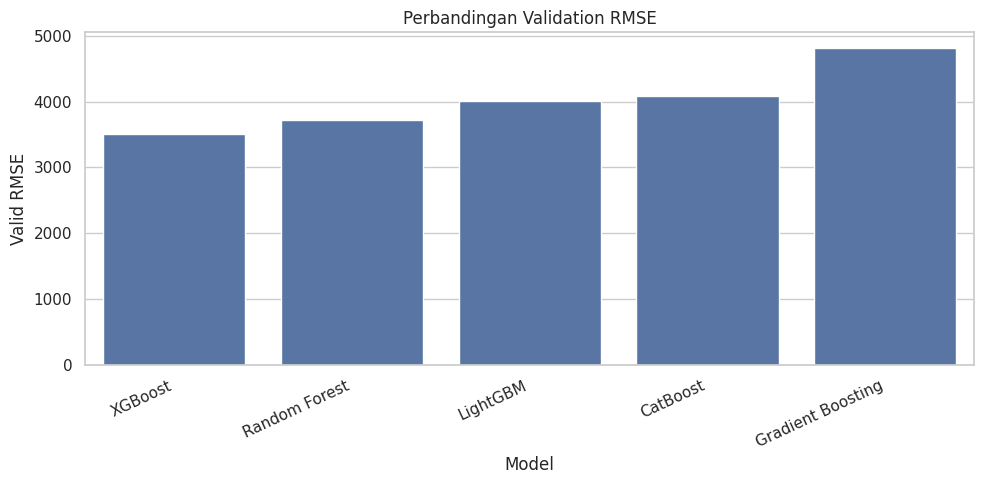

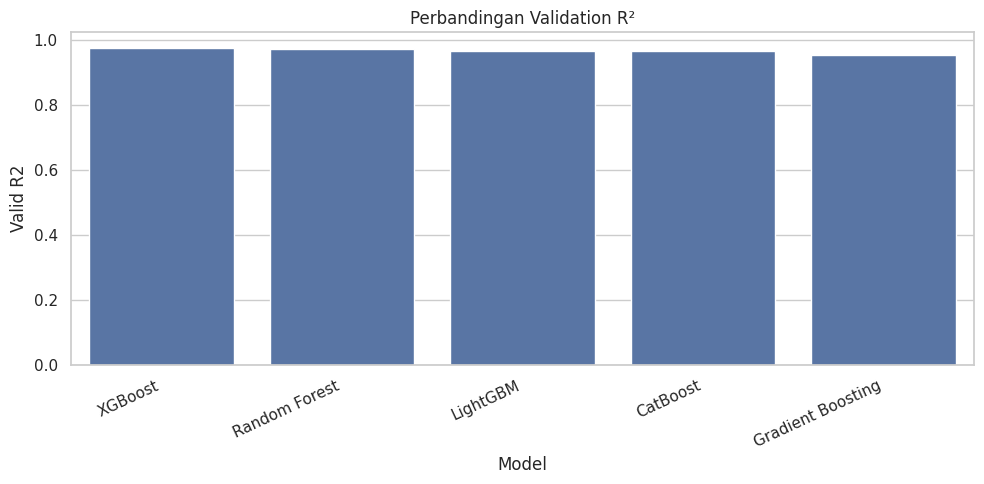

In [27]:
plt.figure(figsize=(10, 5))
sns.barplot(
    data=initial_results_df,
    x='Model',
    y='Valid RMSE'
)
plt.title('Perbandingan Validation RMSE')
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
sns.barplot(
    data=initial_results_df,
    x='Model',
    y='Valid R2'
)
plt.title('Perbandingan Validation R²')
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.show()

#### Penjelasan kode: visualisasi perbandingan model

- Grafik pertama membandingkan Validation RMSE. Model dengan batang lebih rendah memiliki error kuadrat rata-rata yang lebih kecil.
- Grafik kedua membandingkan Validation R². Model dengan batang lebih tinggi menjelaskan variasi harga lebih baik.
- Kedua metrik dibaca bersama karena satu metrik saja tidak selalu cukup menggambarkan kualitas model.
- `tight_layout()` menyesuaikan posisi elemen grafik agar judul dan label tidak terpotong.


## 11. Cross-Validation

Cross-validation tidak secara otomatis memperbaiki overfitting. Fungsinya adalah:

- Mengukur kestabilan performa pada beberapa pembagian data.
- Mengurangi ketergantungan pada satu validation split.
- Menjadi dasar yang lebih kuat untuk memilih dan melakukan tuning model.

Cross-validation hanya dijalankan pada gabungan train dan validation. Test set tetap tidak disentuh.

In [28]:
CV_FOLDS = 3  # Ubah menjadi 5 untuk evaluasi final yang lebih ketat.

cv = KFold(
    n_splits=CV_FOLDS,
    shuffle=True,
    random_state=RANDOM_STATE
)

scoring = {
    'r2': 'r2',
    'mae': 'neg_mean_absolute_error',
    'rmse': 'neg_root_mean_squared_error'
}

cv_rows = []

for model_name, pipeline in pipelines.items():
    print(f'Cross-validating {model_name} ...')

    cv_result = cross_validate(
        estimator=pipeline,
        X=X_train_val,
        y=y_train_val,
        cv=cv,
        scoring=scoring,
        return_train_score=True,
        n_jobs=1,
        error_score='raise'
    )

    train_r2 = cv_result['train_r2'].mean()
    valid_r2 = cv_result['test_r2'].mean()
    train_rmse = -cv_result['train_rmse'].mean()
    valid_rmse = -cv_result['test_rmse'].mean()

    cv_rows.append({
        'Model': model_name,
        'CV Train R2 Mean': train_r2,
        'CV Valid R2 Mean': valid_r2,
        'CV Valid R2 Std': cv_result['test_r2'].std(),
        'CV Valid MAE Mean': -cv_result['test_mae'].mean(),
        'CV Valid RMSE Mean': valid_rmse,
        'CV Valid RMSE Std': cv_result['test_rmse'].std(),
        'CV R2 Gap': train_r2 - valid_r2,
        'CV RMSE Ratio': valid_rmse / max(train_rmse, 1e-12),
        'Potential Overfit CV': (
            (train_r2 - valid_r2) > 0.05
            or valid_rmse / max(train_rmse, 1e-12) > 1.25
        )
    })

cv_results_df = (
    pd.DataFrame(cv_rows)
    .sort_values(['CV Valid RMSE Mean', 'CV Valid MAE Mean'])
    .reset_index(drop=True)
)

display(cv_results_df)

Cross-validating Random Forest ...
Cross-validating XGBoost ...
Cross-validating LightGBM ...
Cross-validating CatBoost ...
Cross-validating Gradient Boosting ...


,Model,CV Train R2 Mean,CV Valid R2 Mean,CV Valid R2 Std,CV Valid MAE Mean,CV Valid RMSE Mean,CV Valid RMSE Std,CV R2 Gap,CV RMSE Ratio,Potential Overfit CV
0,XGBoost,0.99,0.98,0.00,"1,915.83","3,472.25",18.63,0.01,1.32,True
1,Random Forest,0.98,0.97,0.00,"1,950.98","3,706.83",26.85,0.01,1.29,True
2,LightGBM,0.97,0.97,0.00,"2,275.15","3,947.78",11.62,0.00,1.09,False
3,CatBoost,0.97,0.97,0.00,"2,325.65","4,016.49",12.08,0.00,1.07,False
4,Gradient Boosting,0.96,0.96,0.00,"2,767.52","4,695.22",29.96,0.00,1.02,False


#### Penjelasan kode: cross-validation dan kestabilan performa

- `CV_FOLDS = 3` membagi data train-validation menjadi tiga lipatan. Nilai 5 dapat dipakai untuk evaluasi lebih stabil, tetapi membutuhkan waktu komputasi lebih lama.
- `KFold` mengacak data sebelum pembagian dan menggunakan seed tetap.
- Dictionary `scoring` meminta R², MAE, dan RMSE pada setiap fold.
- Scikit-learn menggunakan nilai negatif untuk loss seperti MAE dan RMSE agar semua scorer mengikuti prinsip “semakin besar semakin baik”. Karena itu, hasil dikalikan -1 saat disajikan.
- `cross_validate()` melatih model berulang kali. Pada setiap iterasi, satu fold menjadi validation dan fold lainnya menjadi training.
- `return_train_score=True` memungkinkan perbandingan performa training dan validation.
- `n_jobs=1` menghindari penggunaan memori berlebihan karena beberapa model sudah melakukan paralelisasi internal.
- Mean mengukur performa rata-rata, sedangkan standar deviasi mengukur kestabilan antar-fold.
- Test set tetap tidak digunakan pada tahap ini.
- Model diurutkan berdasarkan rata-rata CV RMSE dan CV MAE terendah.


## 12. Hyperparameter Tuning untuk Model Terbaik

Model terbaik dipilih berdasarkan rata-rata CV RMSE terendah. Tuning dilakukan menggunakan `RandomizedSearchCV`.

Parameter yang dicoba menekankan kontrol kompleksitas, misalnya kedalaman pohon, minimum jumlah sampel, subsampling, dan regularisasi.

In [29]:
best_model_name = cv_results_df.iloc[0]['Model']
best_base_pipeline = pipelines[best_model_name]

parameter_spaces = {
    'Random Forest': {
        'model__n_estimators': [150, 250, 350],
        'model__max_depth': [12, 16, 20, None],
        'model__min_samples_leaf': [2, 4, 8],
        'model__min_samples_split': [2, 5, 10],
        'model__max_features': ['sqrt', 0.7, 1.0]
    },

    'XGBoost': {
        'model__n_estimators': [250, 400, 600],
        'model__learning_rate': [0.03, 0.05, 0.08],
        'model__max_depth': [4, 6, 8],
        'model__min_child_weight': [1, 3, 5],
        'model__subsample': [0.7, 0.85, 1.0],
        'model__colsample_bytree': [0.7, 0.85, 1.0],
        'model__reg_lambda': [1.0, 5.0, 10.0]
    },

    'LightGBM': {
        'model__n_estimators': [250, 400, 600],
        'model__learning_rate': [0.03, 0.05, 0.08],
        'model__num_leaves': [15, 31, 63],
        'model__max_depth': [-1, 8, 12],
        'model__min_child_samples': [20, 40, 80],
        'model__subsample': [0.7, 0.85, 1.0],
        'model__colsample_bytree': [0.7, 0.85, 1.0],
        'model__reg_lambda': [1.0, 5.0, 10.0]
    },

    'CatBoost': {
        'model__iterations': [250, 400, 600],
        'model__learning_rate': [0.03, 0.05, 0.08],
        'model__depth': [5, 7, 9],
        'model__l2_leaf_reg': [3, 5, 10],
        'model__random_strength': [0.5, 1.0, 2.0]
    },

    'Gradient Boosting': {
        'model__n_estimators': [100, 150, 250],
        'model__learning_rate': [0.03, 0.05, 0.08],
        'model__max_depth': [2, 3, 4],
        'model__min_samples_leaf': [3, 5, 10],
        'model__subsample': [0.7, 0.85, 1.0]
    }
}

print('Best model before tuning:', best_model_name)

tuner = RandomizedSearchCV(
    estimator=best_base_pipeline,
    param_distributions=parameter_spaces[best_model_name],
    n_iter=12,
    scoring='neg_root_mean_squared_error',
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=1,
    verbose=1,
    return_train_score=True
)

tuner.fit(X_train_val, y_train_val)

print('Best CV RMSE:', -tuner.best_score_)
print('Best parameters:')
display(tuner.best_params_)

final_model = tuner.best_estimator_

Best model before tuning: XGBoost
Fitting 3 folds for each of 12 candidates, totalling 36 fits
Best CV RMSE: 3365.2364908854165
Best parameters:


{'model__subsample': 0.7,
 'model__reg_lambda': 1.0,
 'model__n_estimators': 400,
 'model__min_child_weight': 5,
 'model__max_depth': 8,
 'model__learning_rate': 0.08,
 'model__colsample_bytree': 1.0}

#### Penjelasan kode: hyperparameter tuning model terbaik

- Model dasar terbaik diambil dari baris pertama `cv_results_df`, yaitu model dengan rata-rata CV RMSE terendah.
- `parameter_spaces` menyediakan kandidat hyperparameter khusus untuk setiap algoritma.
- Awalan `model__` menunjukkan bahwa parameter tersebut dimiliki langkah `model` di dalam pipeline.
- `RandomizedSearchCV` tidak mencoba seluruh kombinasi. Metode ini memilih 12 kombinasi secara acak sehingga lebih hemat waktu daripada grid search penuh.
- Setiap kombinasi dinilai menggunakan negative RMSE pada cross-validation yang sama.
- `random_state` membuat pemilihan kombinasi dapat direproduksi.
- `tuner.fit(X_train_val, y_train_val)` melakukan seluruh proses pencarian pada gabungan train dan validation. Test set masih belum disentuh.
- `best_score_` dikalikan -1 agar kembali menjadi RMSE positif.
- `best_params_` menunjukkan konfigurasi terbaik yang ditemukan.
- `best_estimator_` sudah berupa pipeline yang terlatih dengan parameter terbaik dan disimpan sebagai `final_model`.


## 13. Evaluasi Final pada Test Set dan Pemeriksaan Overfitting Ulang

Test set digunakan pada tahap ini untuk evaluasi final. Performa train–validation gabungan dibandingkan dengan test untuk melihat generalisasi setelah tuning.

In [30]:
final_train_pred = final_model.predict(X_train_val)
final_test_pred = final_model.predict(X_test)

final_train_metrics = regression_metrics(y_train_val, final_train_pred)
final_test_metrics = regression_metrics(y_test, final_test_pred)

final_r2_gap = final_train_metrics['R2'] - final_test_metrics['R2']
final_rmse_ratio = (
    final_test_metrics['RMSE']
    / max(final_train_metrics['RMSE'], 1e-12)
)

final_evaluation = pd.DataFrame([{
    'Final Model': best_model_name,
    'Train MAE': final_train_metrics['MAE'],
    'Test MAE': final_test_metrics['MAE'],
    'Train RMSE': final_train_metrics['RMSE'],
    'Test RMSE': final_test_metrics['RMSE'],
    'Train R2': final_train_metrics['R2'],
    'Test R2': final_test_metrics['R2'],
    'Test MAPE (%)': final_test_metrics['MAPE (%)'],
    'R2 Gap': final_r2_gap,
    'RMSE Ratio': final_rmse_ratio,
    'Potential Overfit After Tuning': (
        final_r2_gap > 0.05 or final_rmse_ratio > 1.25
    )
}])

display(final_evaluation)

,Final Model,Train MAE,Test MAE,Train RMSE,Test RMSE,Train R2,Test R2,Test MAPE (%),R2 Gap,RMSE Ratio,Potential Overfit After Tuning
0,XGBoost,"1,286.81","1,706.58","2,251.78","3,095.19",0.99,0.98,12.28,0.01,1.37,True


#### Penjelasan kode: evaluasi final pada test set

- `final_model` memprediksi gabungan train-validation dan test set.
- Metrik training digunakan sebagai pembanding, sedangkan metrik test menggambarkan kemampuan generalisasi pada data yang tidak digunakan saat pemilihan model.
- `final_r2_gap` menghitung penurunan R² dari training ke test.
- `final_rmse_ratio` membandingkan besar RMSE test terhadap RMSE training.
- Kolom `Potential Overfit After Tuning` menandai model ketika selisih R² lebih dari 0,05 atau rasio RMSE lebih dari 1,25.
- Penanda ini bersifat diagnostik. Model tetap perlu dinilai dari besarnya error aktual, variasi antar-fold, dan kebutuhan aplikasi.


,airline,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,route,actual_price,predicted_price,error,absolute_error,absolute_percentage_error
0,Air_India,Hyderabad,Night,zero,Night,Delhi,Economy,2.17,24,Hyderabad → Delhi,2276,"2,703.56",-427.56,427.56,18.79
1,AirAsia,Mumbai,Afternoon,one,Night,Delhi,Economy,9.17,26,Mumbai → Delhi,2336,"2,431.90",-95.90,95.90,4.11
2,Vistara,Hyderabad,Afternoon,one,Evening,Kolkata,Economy,7.00,49,Hyderabad → Kolkata,7767,"7,179.33",587.67,587.67,7.57
3,Vistara,Mumbai,Afternoon,one,Night,Bangalore,Economy,7.58,47,Mumbai → Bangalore,6450,"6,172.48",277.52,277.52,4.30
4,Indigo,Bangalore,Morning,one,Evening,Mumbai,Economy,6.83,29,Bangalore → Mumbai,5178,"5,033.28",144.72,144.72,2.79
5,Air_India,Bangalore,Morning,one,Night,Kolkata,Business,11.92,11,Bangalore → Kolkata,60508,"58,998.06","1,509.94","1,509.94",2.50
6,Vistara,Mumbai,Morning,one,Night,Hyderabad,Economy,11.83,21,Mumbai → Hyderabad,3334,"4,464.73","-1,130.73","1,130.73",33.92
7,GO_FIRST,Chennai,Afternoon,zero,Afternoon,Mumbai,Economy,1.92,17,Chennai → Mumbai,3000,"3,120.34",-120.34,120.34,4.01
8,Air_India,Chennai,Afternoon,one,Morning,Bangalore,Business,20.25,38,Chennai → Bangalore,43729,"46,172.60","-2,443.60","2,443.60",5.59
9,Air_India,Kolkata,Morning,one,Night,Mumbai,Economy,11.75,47,Kolkata → Mumbai,5102,"5,355.60",-253.60,253.60,4.97


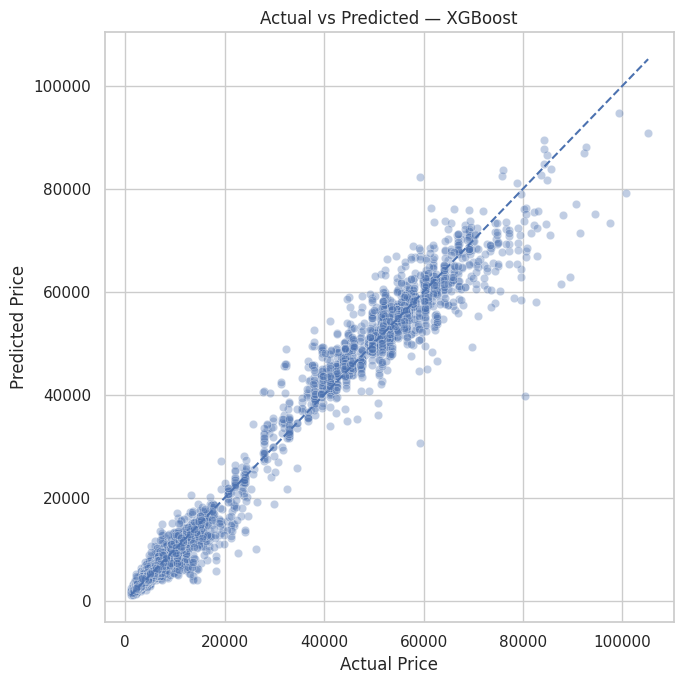

In [31]:
prediction_check = X_test.copy().reset_index(drop=True)
prediction_check['actual_price'] = y_test.reset_index(drop=True)
prediction_check['predicted_price'] = final_test_pred
prediction_check['error'] = (
    prediction_check['actual_price']
    - prediction_check['predicted_price']
)
prediction_check['absolute_error'] = prediction_check['error'].abs()
prediction_check['absolute_percentage_error'] = (
    prediction_check['absolute_error']
    / prediction_check['actual_price']
    * 100
)

display(prediction_check.head(10))

plt.figure(figsize=(7, 7))
plot_sample = prediction_check.sample(
    n=min(5000, len(prediction_check)),
    random_state=RANDOM_STATE
)

sns.scatterplot(
    data=plot_sample,
    x='actual_price',
    y='predicted_price',
    alpha=0.35
)

limit_min = min(
    plot_sample['actual_price'].min(),
    plot_sample['predicted_price'].min()
)
limit_max = max(
    plot_sample['actual_price'].max(),
    plot_sample['predicted_price'].max()
)

plt.plot([limit_min, limit_max], [limit_min, limit_max], linestyle='--')
plt.title(f'Actual vs Predicted — {best_model_name}')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.tight_layout()
plt.show()

#### Penjelasan kode: pemeriksaan prediksi individual dan scatter plot

- Salinan `X_test` dibuat agar fitur asli dapat ditampilkan bersama hasil prediksi.
- `actual_price` berisi harga sebenarnya dan `predicted_price` berisi keluaran model.
- `error = actual - predicted`. Nilai positif berarti model memprediksi terlalu rendah, sedangkan nilai negatif berarti model memprediksi terlalu tinggi.
- `absolute_error` mengabaikan arah kesalahan dan hanya mengukur besar selisih.
- `absolute_percentage_error` menyatakan besar error relatif terhadap harga aktual.
- Maksimal 5.000 baris diambil untuk scatter plot agar visualisasi tetap ringan.
- Garis putus-putus merepresentasikan prediksi sempurna, yaitu `predicted_price = actual_price`.
- Titik yang dekat dengan garis menunjukkan prediksi yang lebih akurat. Pola sistematis di atas atau di bawah garis dapat menunjukkan bias model.


In [32]:
error_by_class = (
    prediction_check
    .groupby('class')
    .apply(lambda group: pd.Series({
        'Count': len(group),
        'Actual Mean': group['actual_price'].mean(),
        'Predicted Mean': group['predicted_price'].mean(),
        'MAE': group['absolute_error'].mean(),
        'RMSE': np.sqrt(
            mean_squared_error(
                group['actual_price'],
                group['predicted_price']
            )
        ),
        'MAPE (%)': group['absolute_percentage_error'].mean()
    }))
    .reset_index()
)

display(error_by_class)

,class,Count,Actual Mean,Predicted Mean,MAE,RMSE,MAPE (%)
0,Business,"2,806.00","52,271.88","52,293.06","3,322.24","4,997.30",6.41
1,Economy,"6,194.00","6,657.63","6,665.83",974.65,"1,614.61",14.94


#### Penjelasan kode: analisis error per kelas penerbangan

- Data prediksi dikelompokkan berdasarkan `class`.
- Fungsi lambda menghitung jumlah observasi, rata-rata harga aktual, rata-rata prediksi, MAE, RMSE, dan MAPE pada setiap kelas.
- Analisis agregat ini penting karena performa keseluruhan dapat menyembunyikan kelemahan pada kelompok tertentu.
- Contohnya, model dapat memiliki error keseluruhan rendah tetapi jauh lebih buruk pada Business karena rentang harganya lebih tinggi.
- `.reset_index()` mengubah hasil grouping menjadi DataFrame biasa yang mudah dibaca.


## 14. Menyimpan Model Final ke Google Drive

Model dan metadata disimpan ke folder `MyDrive/Flight_Price_Project/output`. Penyimpanan di Google Drive mencegah file hilang ketika sesi Google Colab berakhir.


In [33]:
# Menentukan folder output permanen di Google Drive.
OUTPUT_DIR = DRIVE_ROOT / 'Flight_Price_Project' / 'output'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Menentukan nama dan lokasi file model serta metadata.
model_path = OUTPUT_DIR / 'flight_price_model_revised.pkl'
metadata_path = OUTPUT_DIR / 'flight_price_model_revised_metadata.json'

# Menyimpan seluruh pipeline final, termasuk preprocessing dan model.
joblib.dump(final_model, model_path, compress=3)

# Menyusun informasi pendukung yang diperlukan saat deployment atau audit model.
metadata = {
    'best_model': best_model_name,
    'model_features': X.columns.tolist(),
    'categorical_features': categorical_features,
    'numeric_features': numeric_features,
    'final_metrics': final_evaluation.to_dict(orient='records')[0],
    'best_parameters': tuner.best_params_,
    'dataset_path': str(data_path)
}

# Menyimpan metadata dalam format JSON yang mudah dibaca manusia.
with metadata_path.open('w', encoding='utf-8') as f:
    json.dump(metadata, f, indent=4, default=str)

print('Model tersimpan pada   :', model_path)
print('Metadata tersimpan pada:', metadata_path)


Model tersimpan pada   : /content/drive/MyDrive/Digital Skola/Final Project/Flight_Price_Project/output/flight_price_model_revised.pkl
Metadata tersimpan pada: /content/drive/MyDrive/Digital Skola/Final Project/Flight_Price_Project/output/flight_price_model_revised_metadata.json


#### Penjelasan kode: menyimpan model dan metadata ke Google Drive

- Folder output dibuat di Google Drive agar file tetap tersedia setelah runtime Colab berakhir.
- `mkdir(parents=True, exist_ok=True)` membuat seluruh folder yang belum tersedia dan tidak menimbulkan error jika folder sudah ada.
- `joblib.dump()` menyimpan pipeline final, termasuk encoder dan model, ke file `.pkl`.
- `compress=3` mengaktifkan kompresi moderat untuk mengurangi ukuran file.
- Metadata disimpan terpisah dalam format JSON. Isinya mencakup nama model, daftar fitur, pembagian tipe fitur, metrik final, dan hyperparameter terbaik.
- `default=str` mencegah kegagalan serialisasi jika ada objek yang bukan tipe JSON standar.
- Model `.pkl` dapat dipakai kembali untuk prediksi tanpa melatih ulang, selama versi library kompatibel.


## 15. Kesimpulan Metodologis

1. Outlier diperiksa menggunakan distribusi, boxplot, dan IQR, tetapi tidak dihapus secara otomatis.
2. Data dibagi menjadi train, validation, dan test untuk mencegah penggunaan test set berulang kali.
3. Encoding dilakukan dengan `OneHotEncoder` di dalam pipeline agar tidak terjadi data leakage.
4. Scaling tidak diterapkan karena seluruh kandidat merupakan model berbasis pohon.
5. Lima model dibandingkan pada data dan preprocessing yang sama.
6. Evaluasi menggunakan MAE, RMSE, R², dan MAPE.
7. Overfitting diperiksa melalui selisih performa train dan validation.
8. Cross-validation digunakan untuk menilai kestabilan dan memilih model.
9. Model terbaik dituning menggunakan cross-validation, lalu overfitting diperiksa kembali pada test set yang sebelumnya tidak digunakan.

## 16. Catatan Menjalankan Notebook

1. Jalankan sel dari atas ke bawah agar setiap variabel tersedia sebelum digunakan.
2. Pastikan akun Google yang digunakan saat otorisasi memiliki akses ke dataset.
3. Jika dataset berada di lokasi berbeda, cukup ubah `DATASET_FOLDER` dan `DATASET_FILENAME`.
4. Jika proses modelling terlalu berat, kecilkan `MODEL_SAMPLE_SIZE`, `CV_FOLDS`, atau `n_iter` pada `RandomizedSearchCV`.
5. Jangan menilai model hanya dari R². Periksa MAE, RMSE, MAPE, kestabilan cross-validation, dan error per kelas.
6. File model final dan metadata akan tersedia pada `MyDrive/Flight_Price_Project/output`.
